# Итоговая контрольная работа

**Датасет:** Weather Timeseries Dataset. Содержит различные метеорологические показатели, собранные с метеостанции.

**Цель задачи:** Прогнозирование температуры на 24 часа вперед (задача регрессии).

## Импорт библиотек и настройка окружения

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.fft import fft

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Исследование данных
Описание датасета, размеров выборки, визуализация временных рядов.

### 1.1 Загрузка датасета и базовая статистика

In [ ]:
df = pd.read_csv('mpi_roof.csv')

columns_to_keep = ['Date Time', 'p (mbar)', 'T (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)']
if all(c in df.columns for c in columns_to_keep):
    df = df[columns_to_keep]

df['Date Time'] = pd.to_datetime(df['Date Time'], format='%Y-%m-%d %H:%M:%S')
df.set_index('Date Time', inplace=True)

print(f"Исходный размер выборки: {df.shape}")
print(df.info())
display(df.describe())

Исходный размер выборки: (1051920, 9)
<class 'pandas.DataFrame'>
DatetimeIndex: 1051920 entries, 2004-01-01 00:10:00 to 2024-01-01 00:00:00
Data columns (total 9 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   p (mbar)         1051920 non-null  float64
 1   T (degC)         1051920 non-null  float64
 2   rh (%)           1051920 non-null  float64
 3   VPmax (mbar)     1051920 non-null  float64
 4   VPact (mbar)     1051920 non-null  float64
 5   VPdef (mbar)     1051920 non-null  float64
 6   sh (g/kg)        1051920 non-null  float64
 7   H2OC (mmol/mol)  1051920 non-null  float64
 8   rho (g/m**3)     1051920 non-null  float64
dtypes: float64(9)
memory usage: 80.3 MB
None


,p (mbar),T (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3)
count,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06,1.051920e+06
mean,9.895526e+02,9.808559e+00,7.556941e+01,1.383621e+01,9.628103e+00,4.208026e+00,6.080787e+00,9.733562e+00,1.214866e+03
std,8.694266e+00,8.236421e+00,1.716658e+01,7.792962e+00,4.125889e+00,5.135452e+00,2.620006e+00,4.177568e+00,3.937482e+01
min,9.136000e+02,-2.301000e+01,1.295000e+01,9.500000e-01,7.900000e-01,0.000000e+00,5.000000e-01,8.000000e-01,1.059450e+03
25%,9.844300e+02,3.640000e+00,6.427000e+01,7.930000e+00,6.330000e+00,9.000000e-01,3.990000e+00,6.400000e+00,1.186290e+03
50%,9.899100e+02,9.640000e+00,7.880000e+01,1.201000e+01,9.000000e+00,2.250000e+00,5.680000e+00,9.090000e+00,1.212950e+03
75%,9.952500e+02,1.570000e+01,8.950000e+01,1.786000e+01,1.244000e+01,5.500000e+00,7.860000e+00,1.257000e+01,1.242060e+03
max,1.020070e+03,3.795000e+01,1.000000e+02,6.613000e+01,2.832000e+01,5.672000e+01,1.813000e+01,2.882000e+01,1.393540e+03


### 1.2 Описание признаков

In [1]:
print("ОПИСАНИЕ ПРИЗНАКОВ:")
print("-" * 40)
print("p (mbar)        : Атмосферное давление (миллибары)")
print("T (degC)        : Температура воздуха - ЦЕЛЕВАЯ ПЕРЕМЕННАЯ")
print("rh (%)          : Относительная влажность (%)")
print("VPmax (mbar)    : Давление насыщенного пара (миллибары)")
print("VPact (mbar)    : Фактическое давление пара (миллибары)")
print("VPdef (mbar)    : Дефицит давления пара (миллибары)")
print("sh (g/kg)       : Удельная влажность (г/кг)")
print("H2OC (mmol/mol) : Концентрация водяного пара (ммоль/моль)")
print("rho (g/m**3)    : Плотность воздуха (г/м³)")

ОПИСАНИЕ ПРИЗНАКОВ:
----------------------------------------
p (mbar)        : Атмосферное давление (миллибары)
T (degC)        : Температура воздуха - ЦЕЛЕВАЯ ПЕРЕМЕННАЯ
rh (%)          : Относительная влажность (%)
VPmax (mbar)    : Давление насыщенного пара (миллибары)
VPact (mbar)    : Фактическое давление пара (миллибары)
VPdef (mbar)    : Дефицит давления пара (миллибары)
sh (g/kg)       : Удельная влажность (г/кг)
H2OC (mmol/mol) : Концентрация водяного пара (ммоль/моль)
rho (g/m**3)    : Плотность воздуха (г/м³)


### 1.3 Визуализация всех признаков

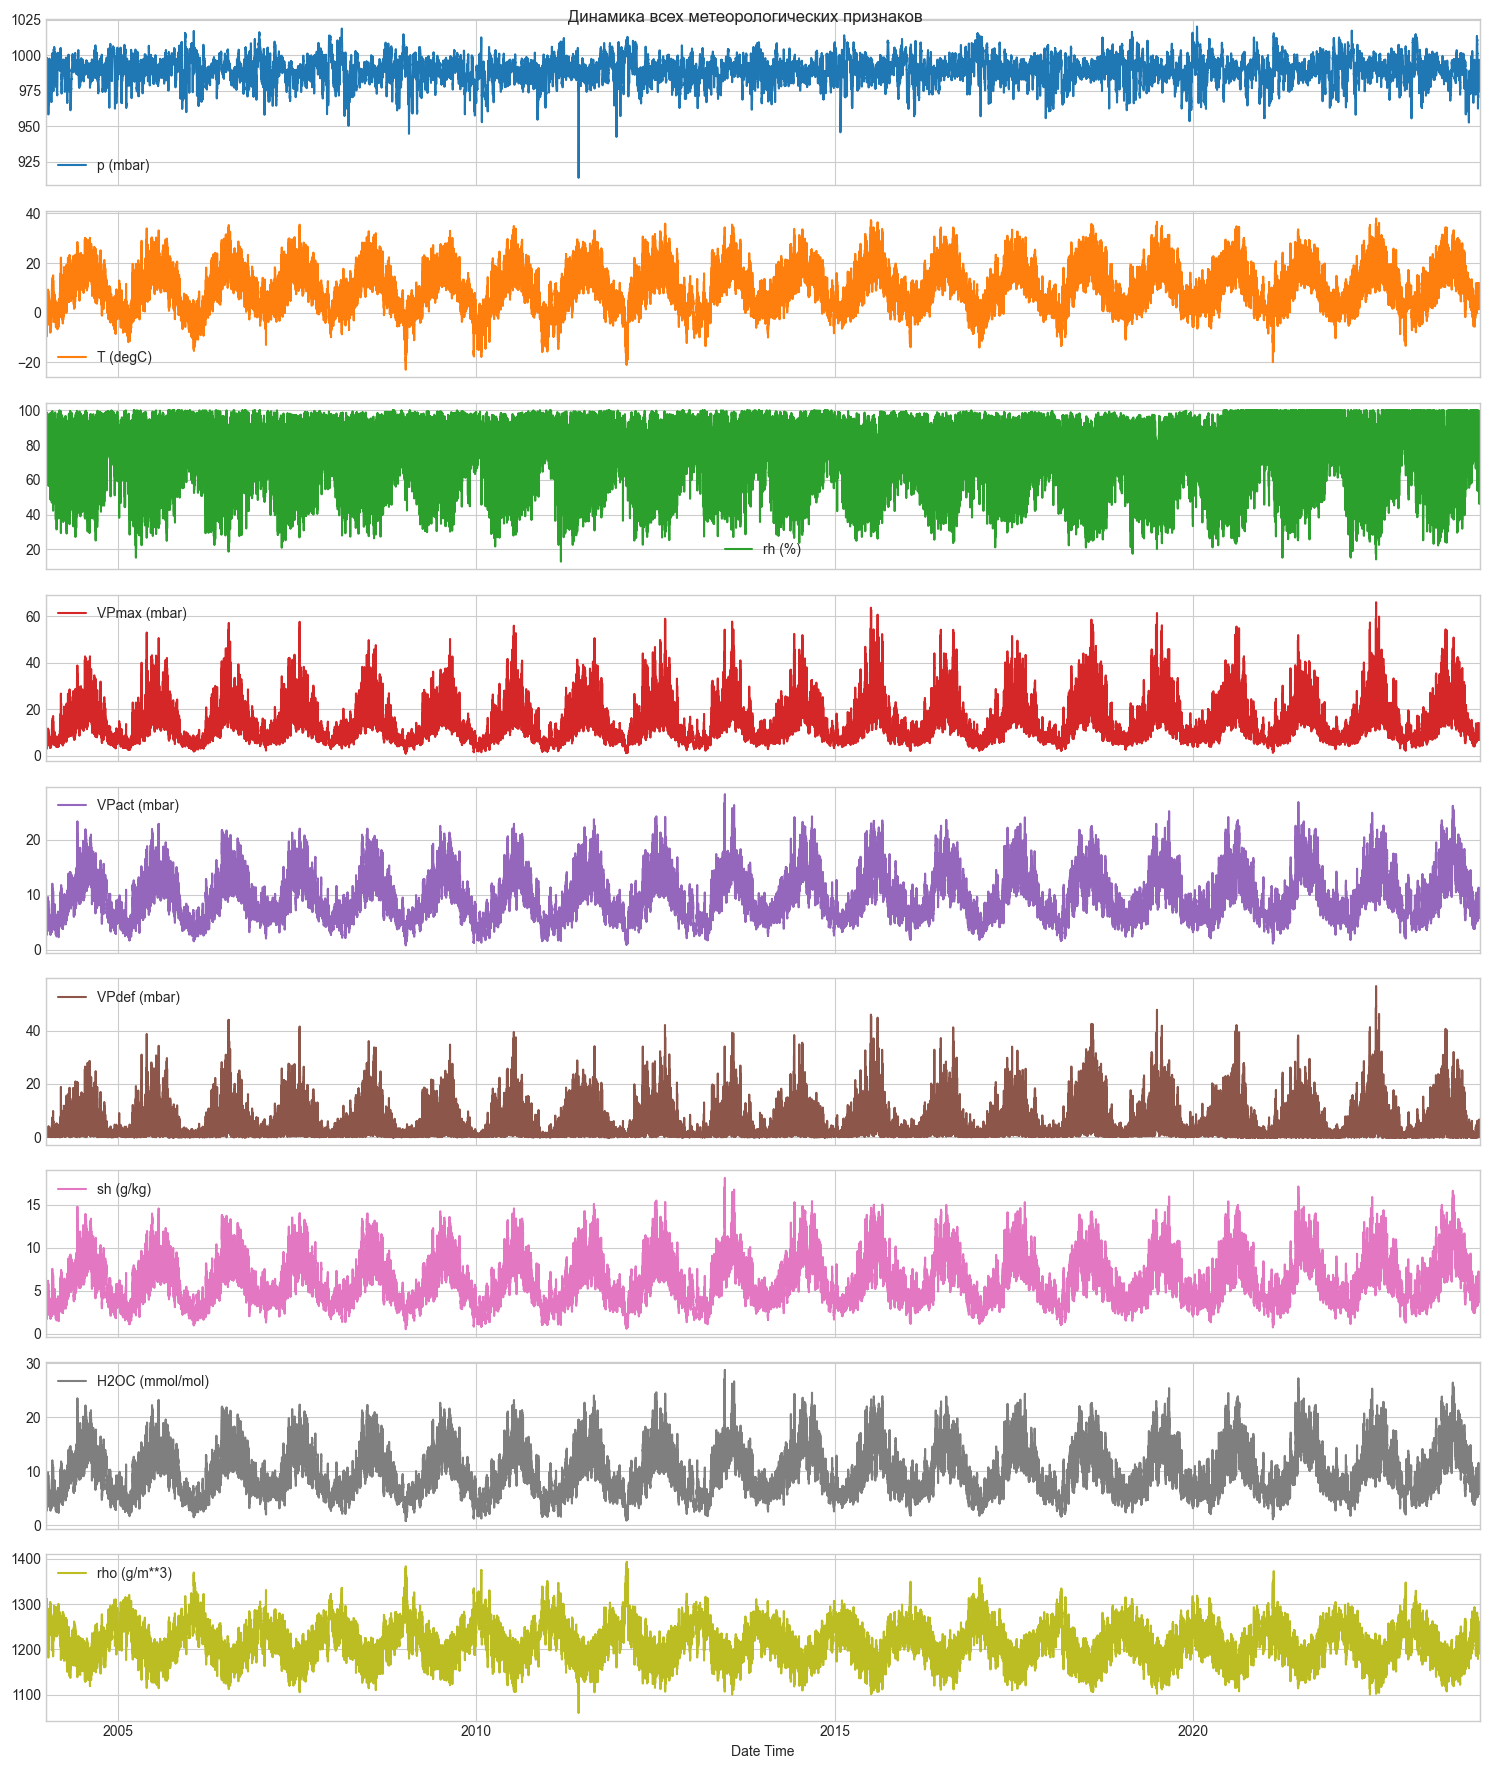

In [ ]:
df.plot(subplots=True, figsize=(15, 18), title="Динамика всех метеорологических признаков")
plt.tight_layout()
plt.show()

### 1.4 Детальный просмотр первых 2 лет

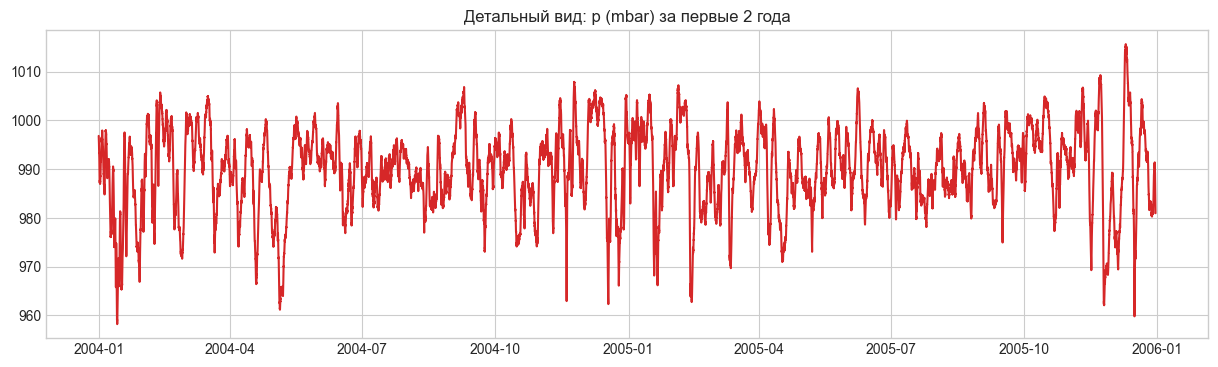

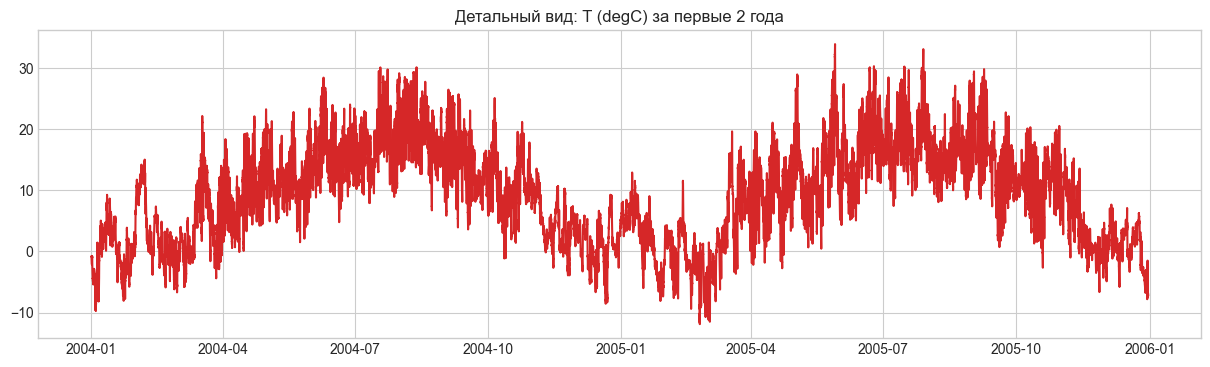

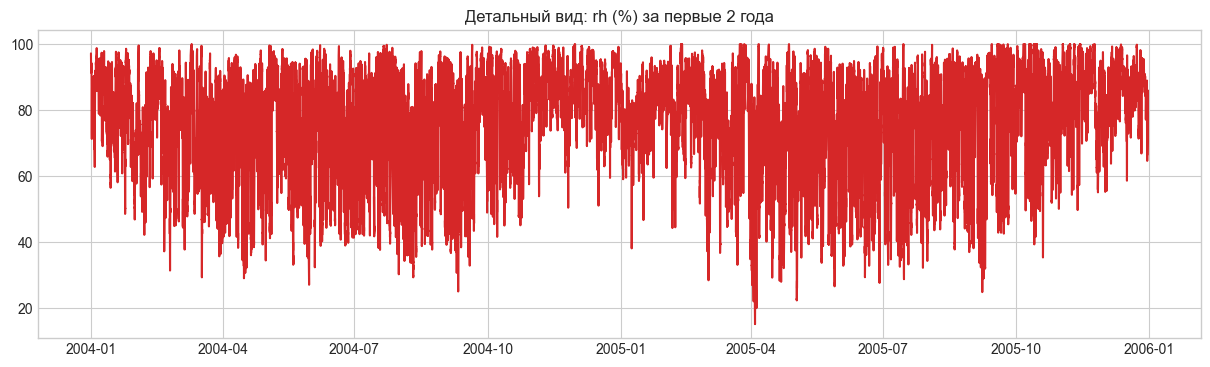

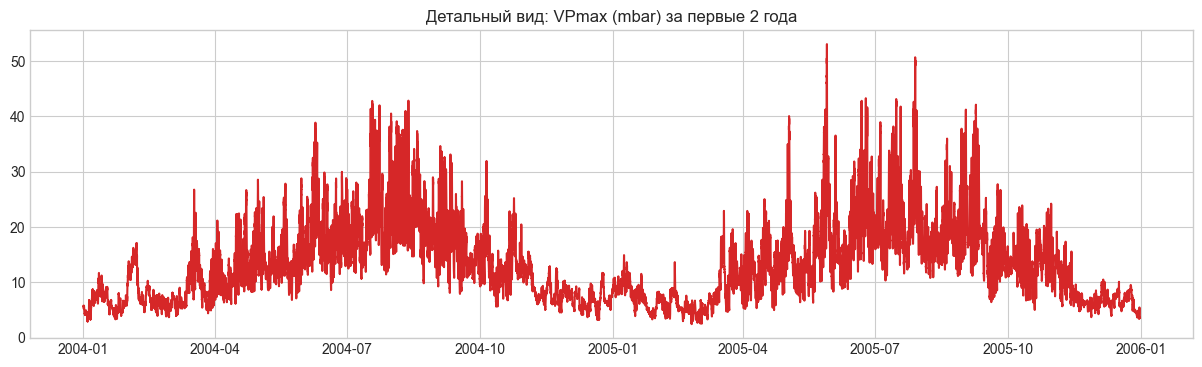

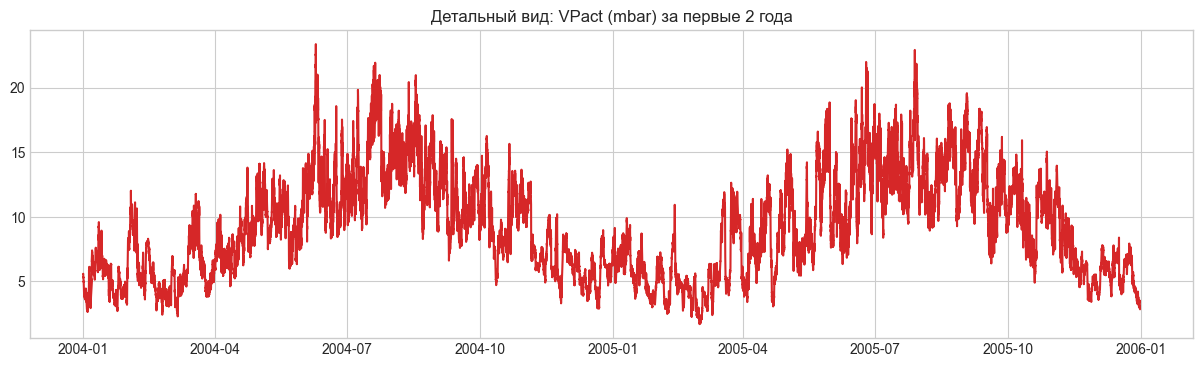

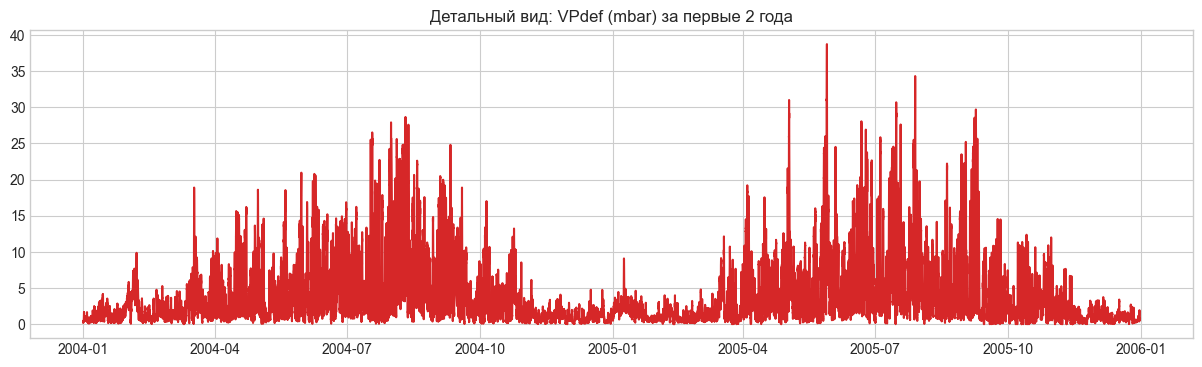

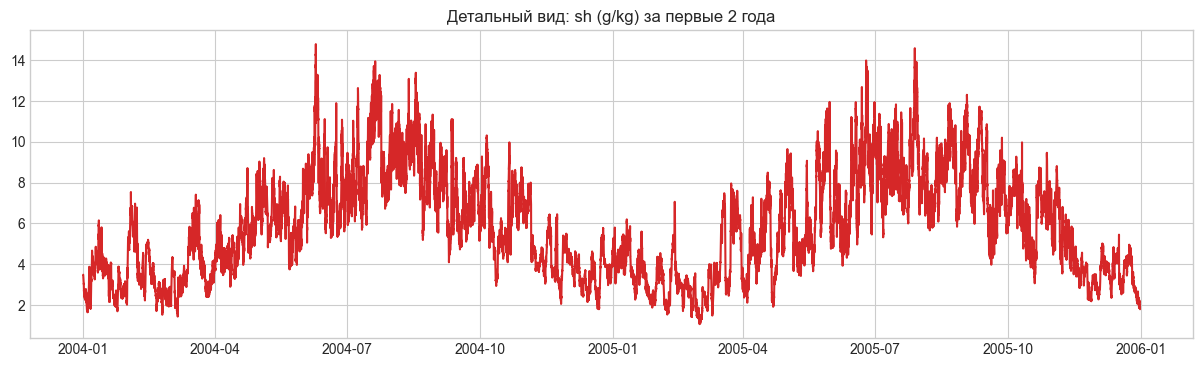

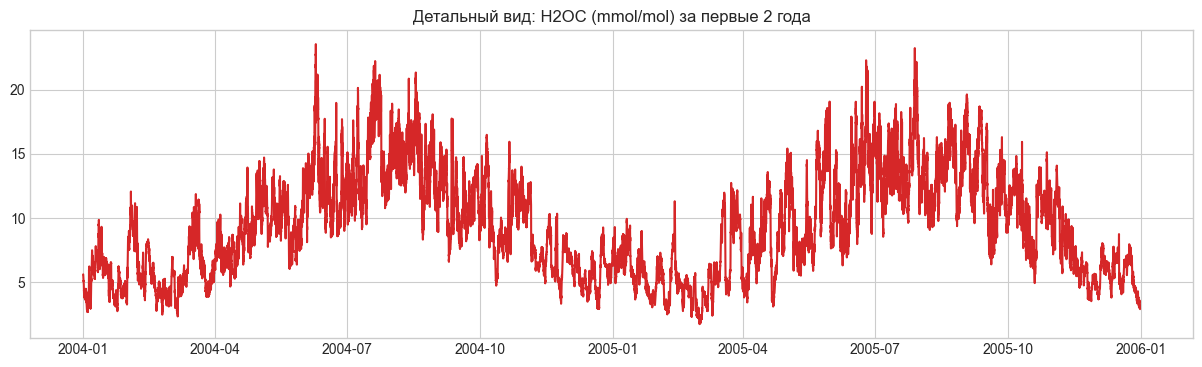

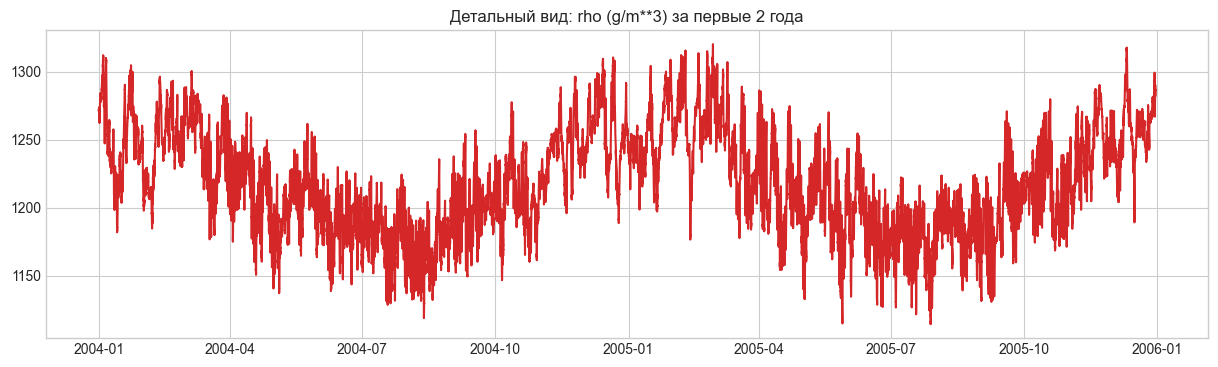

In [ ]:
# 2 года = 2 * 365 * 24 * 6 = 105120 точек
for col in df.columns:
    plt.figure(figsize=(15, 4))
    plt.plot(df.index[:105120], df[col][:105120], color='tab:red')
    plt.title(f'Детальный вид: {col} за первые 2 года')
    plt.show()

## 2. Предобработка временного ряда (EDA и Предобработка)
Анализ стационарности, тренда, сезонности, автокорреляции, выбросов.

### 2.1 Ресемплинг и заполнение пропусков

In [ ]:
df_resampled = df.resample('1h').mean()

print(f"Пропусков до интерполяции:\n{df_resampled.isna().sum().sum()}")
df_resampled = df_resampled.interpolate(method='linear')

Пропусков до интерполяции:
0


### 2.2 Анализ выбросов (boxplots до обработки)

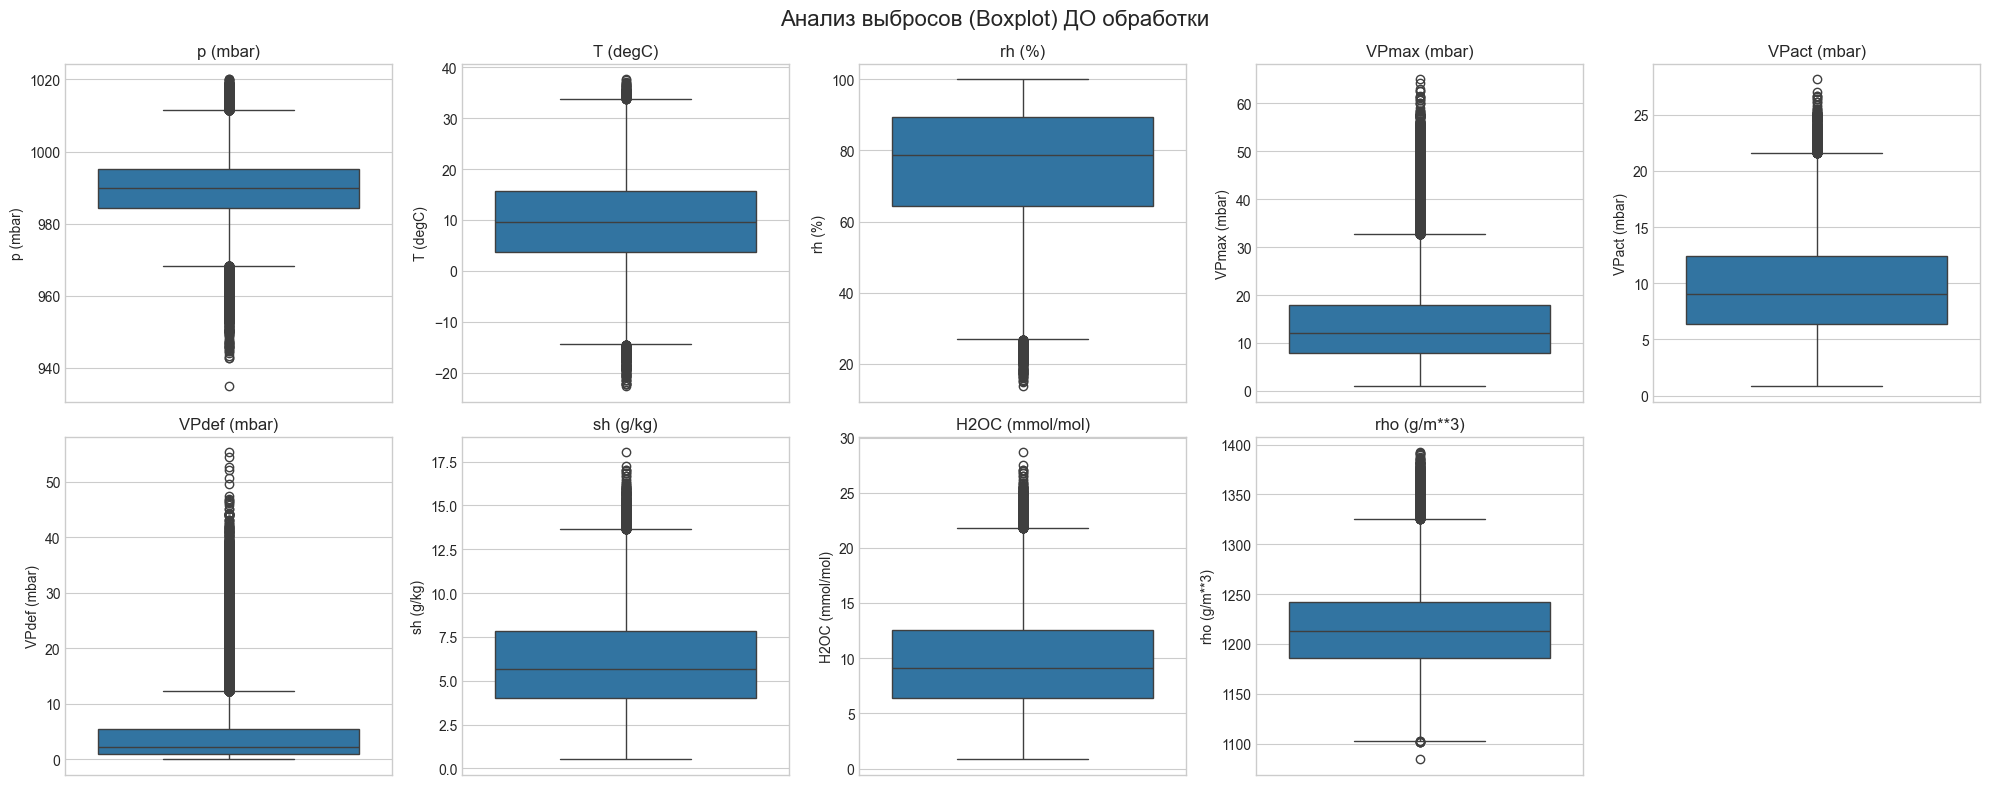

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(df_resampled.columns):
    sns.boxplot(y=df_resampled[col], ax=axes[i])
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Анализ выбросов (Boxplot) ДО обработки', fontsize=16)
plt.tight_layout()
plt.show()

### 2.3 Обработка выбросов методом IQR

Обработка выбросов методом IQR (клиппинг)...


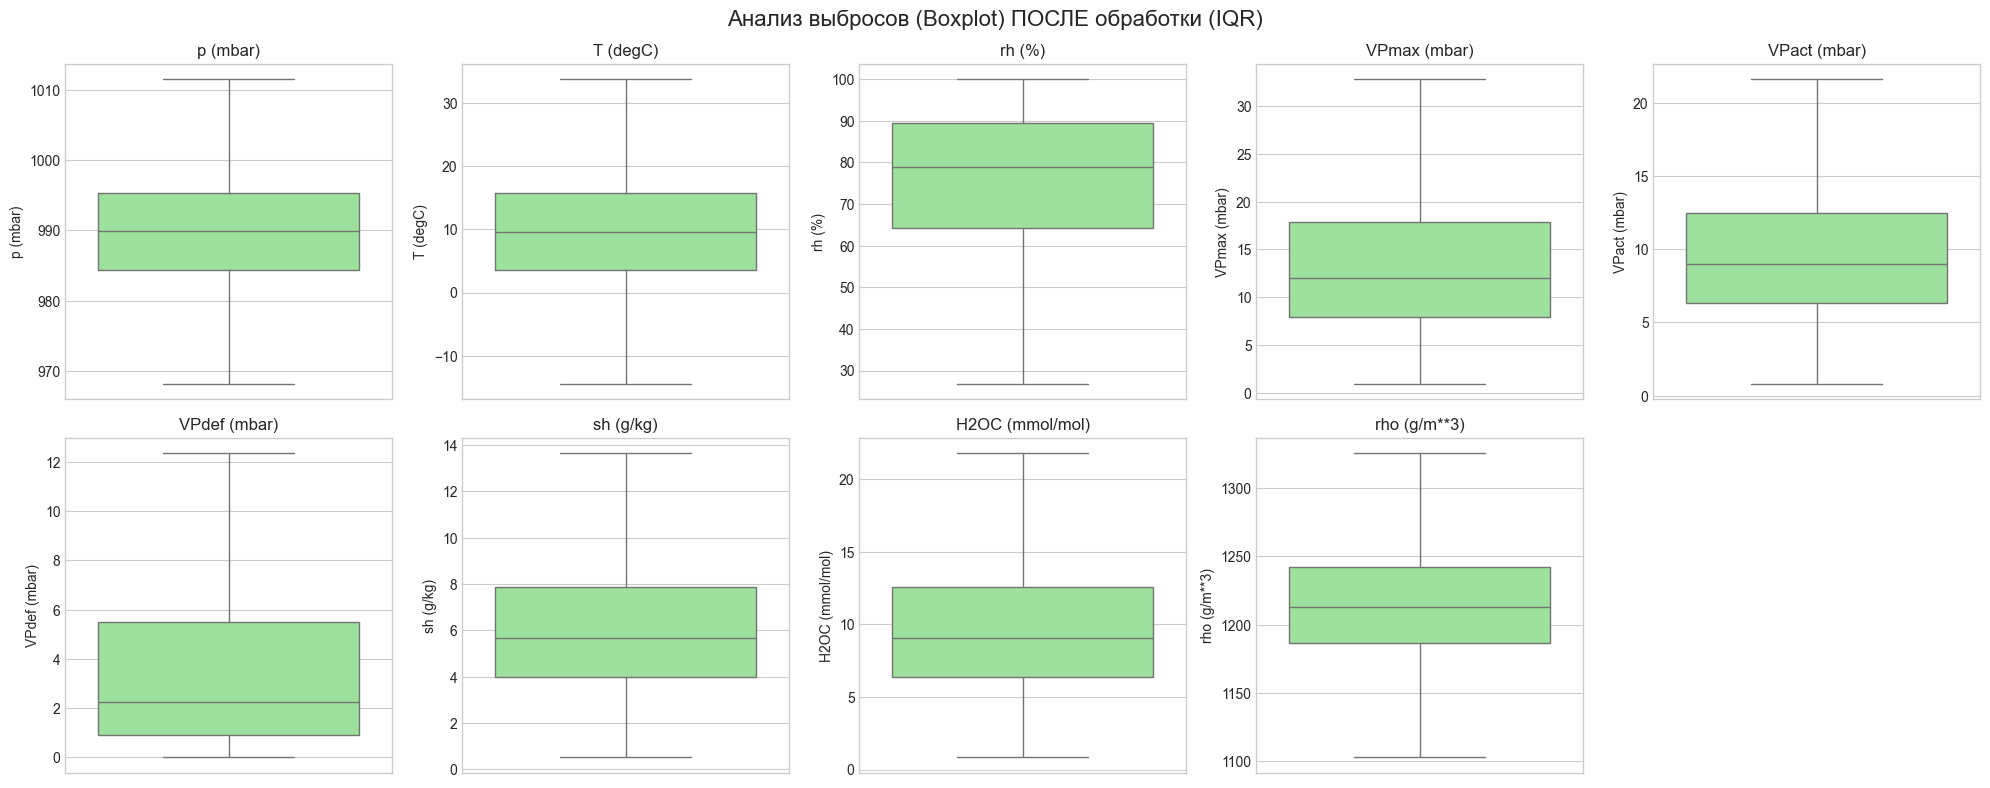

In [ ]:
print("Обработка выбросов методом IQR (клиппинг)...")
for col in df_resampled.columns:
    Q1 = df_resampled[col].quantile(0.25)
    Q3 = df_resampled[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Ограничиваем (clip) экстремальные значения, чтобы не разрывать временной ряд
    df_resampled[col] = df_resampled[col].clip(lower=lower_bound, upper=upper_bound)

# EDA: Выбросы (Boxplots) ПОСЛЕ обработки
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(df_resampled.columns):
    sns.boxplot(y=df_resampled[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Анализ выбросов (Boxplot) ПОСЛЕ обработки (IQR)', fontsize=16)
plt.tight_layout()
plt.show()

### 2.4 тренд и сезонность

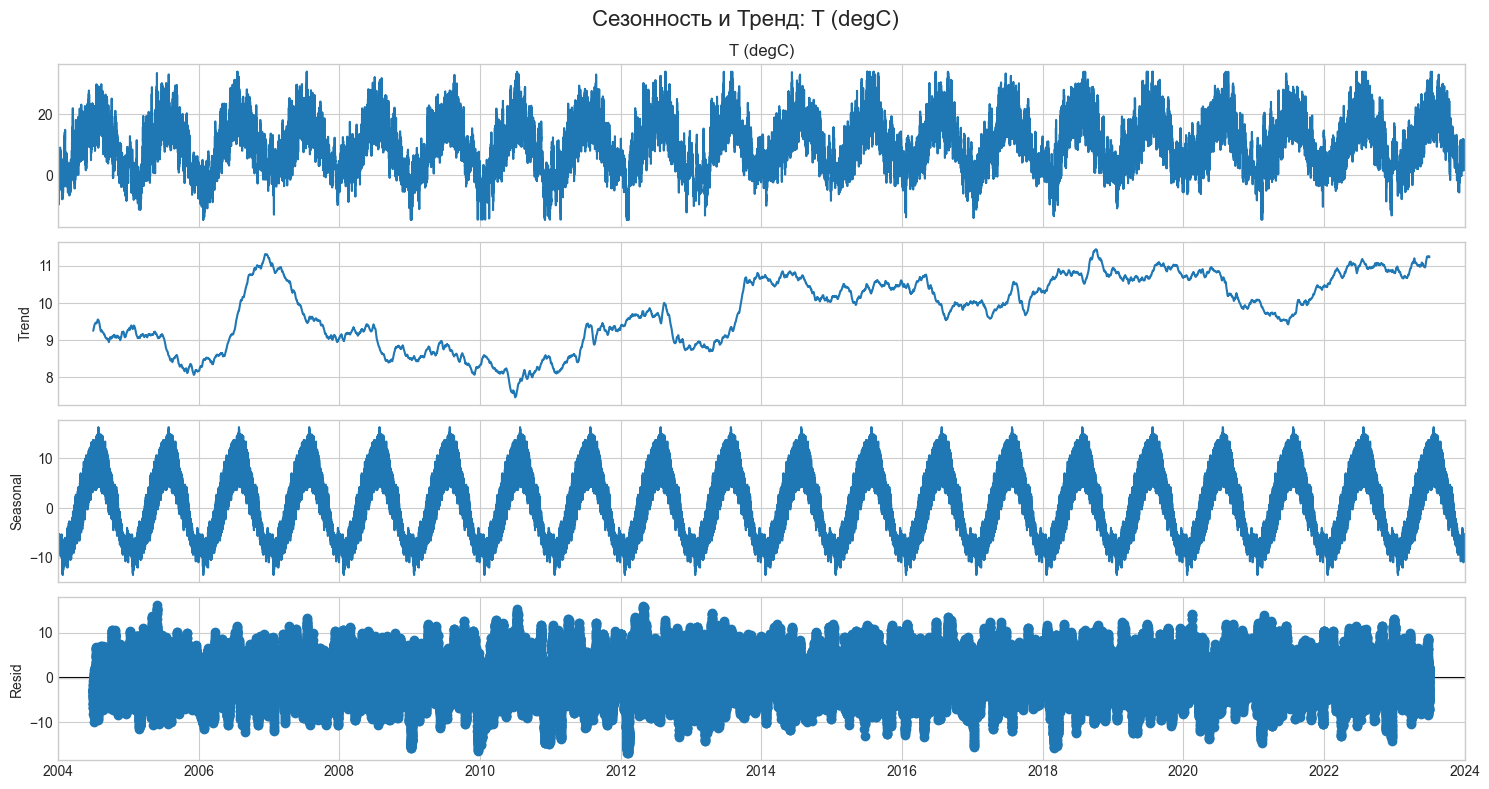

In [ ]:

target_feature = 'T (degC)'
decomp_data = df_resampled[target_feature].dropna()

period = 24 * 365 if len(decomp_data) > 2 * 24 * 365 else 24
decomposition = seasonal_decompose(decomp_data, period=period)
fig = decomposition.plot()
fig.suptitle(f'Сезонность и Тренд: {target_feature}', fontsize=16)
fig.set_size_inches(15, 8)
fig.tight_layout()
plt.show()

### 2.5 Анализ автокорреляции

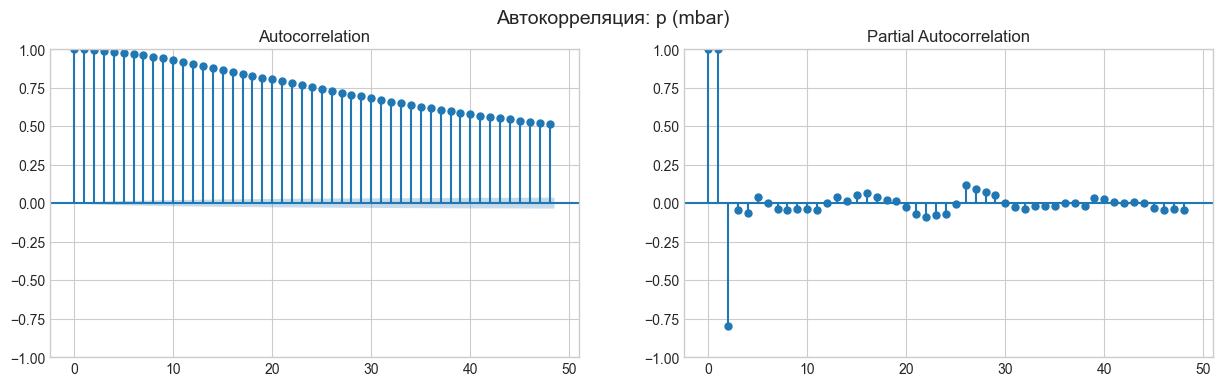

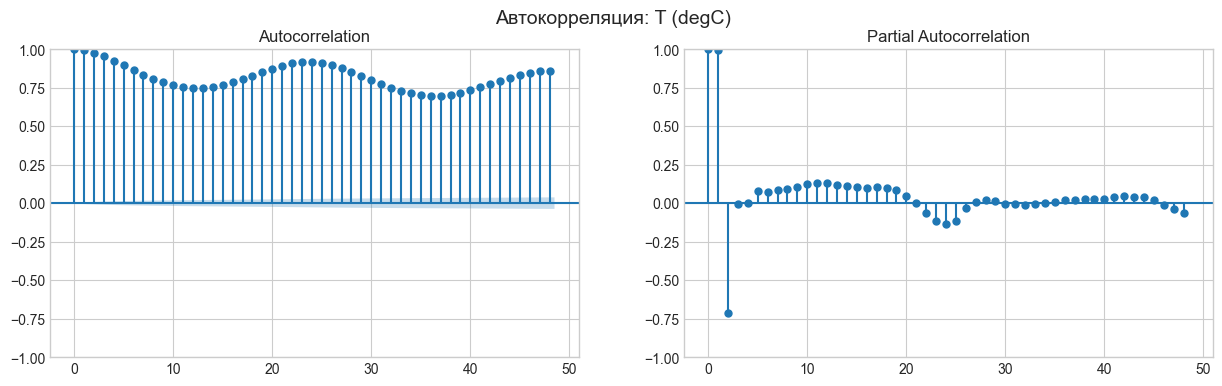

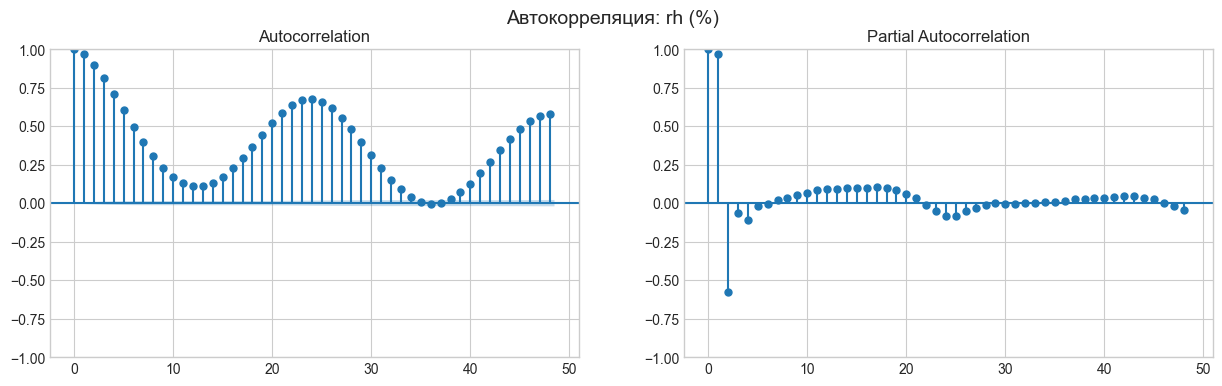

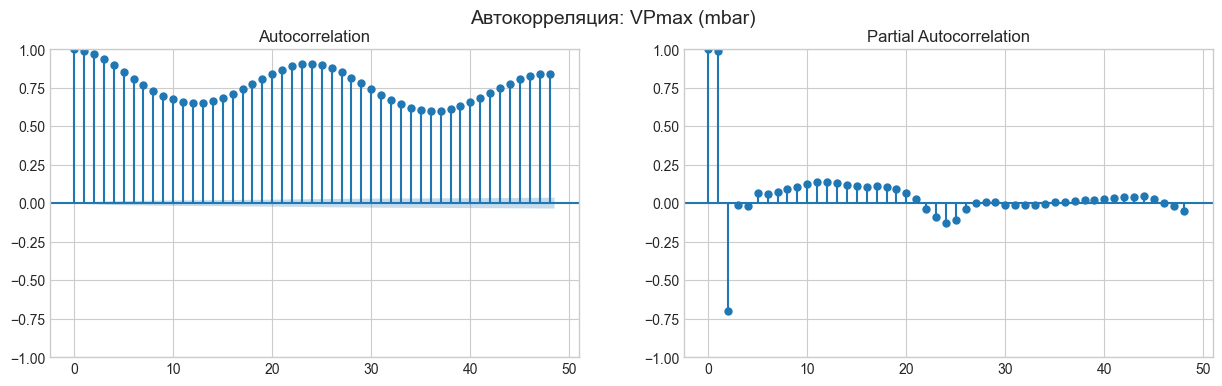

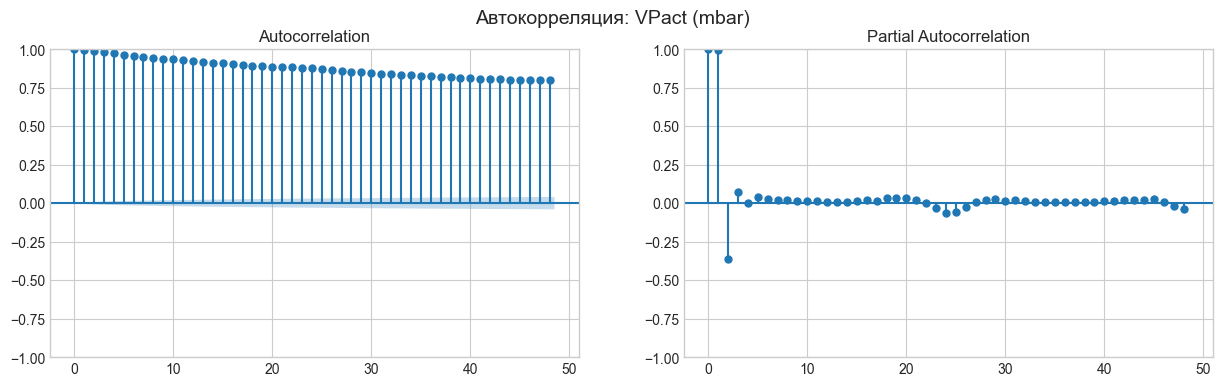

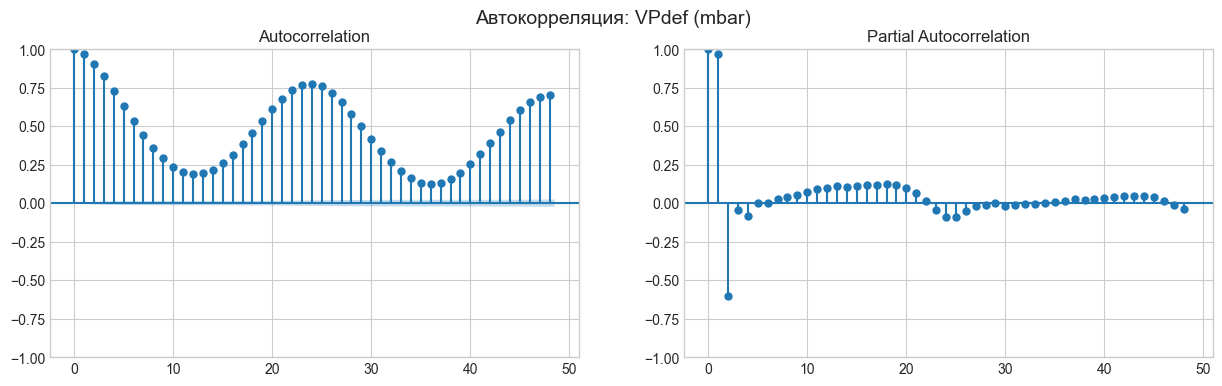

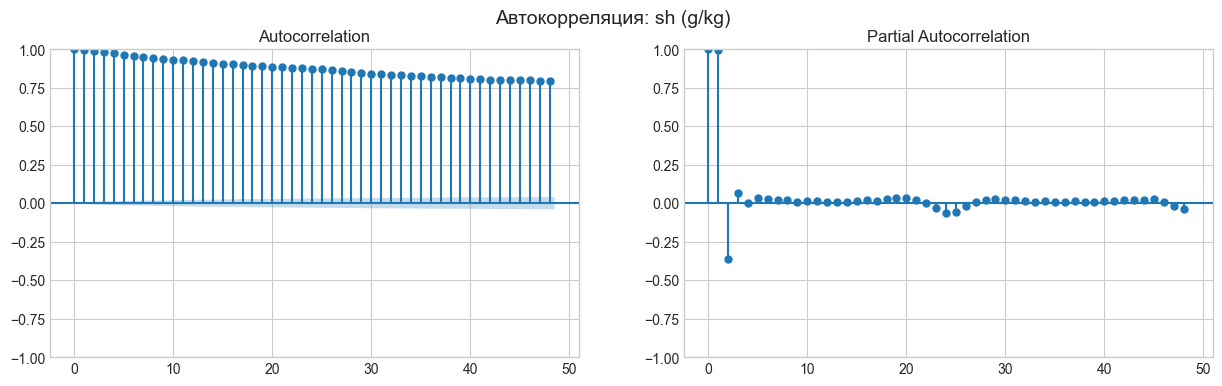

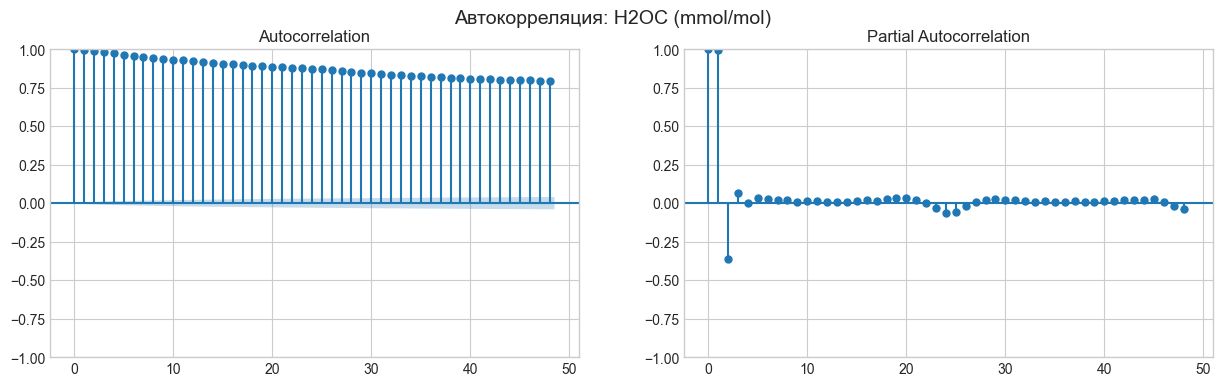

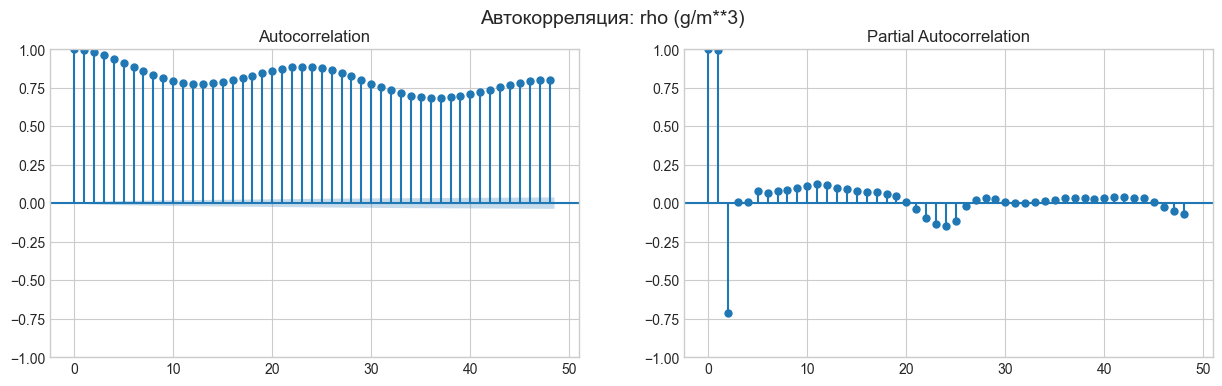

In [ ]:
for col in df_resampled.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    plot_acf(df_resampled[col].dropna(), lags=48, ax=axes[0])
    plot_pacf(df_resampled[col].dropna(), lags=48, ax=axes[1])
    fig.suptitle(f'Автокорреляция: {col}', fontsize=14)
    plt.show()

### 2.6 Проверка стационарности (тест Дики-Фуллера)

In [ ]:
def check_stationarity(series, name):
    result = adfuller(series.dropna())
    print(f'ADF Statistic for {name}: {result[0]:.4f}, p-value: {result[1]:.4f}')
    if result[1] < 0.05:
        print(f"--> Ряд {name} стационарен (отвергаем H0)\n")
    else:
        print(f"--> Ряд {name} нестационарен (принимаем H0)\n")

for col in df_resampled.columns:
    check_stationarity(df_resampled[col], col)

ADF Statistic for p (mbar): -27.0872, p-value: 0.0000
--> Ряд p (mbar) стационарен (отвергаем H0)

ADF Statistic for T (degC): -12.8160, p-value: 0.0000
--> Ряд T (degC) стационарен (отвергаем H0)

ADF Statistic for rh (%): -24.8436, p-value: 0.0000
--> Ряд rh (%) стационарен (отвергаем H0)

ADF Statistic for VPmax (mbar): -13.2791, p-value: 0.0000
--> Ряд VPmax (mbar) стационарен (отвергаем H0)

ADF Statistic for VPact (mbar): -14.5435, p-value: 0.0000
--> Ряд VPact (mbar) стационарен (отвергаем H0)

ADF Statistic for VPdef (mbar): -18.3489, p-value: 0.0000
--> Ряд VPdef (mbar) стационарен (отвергаем H0)

ADF Statistic for sh (g/kg): -14.6388, p-value: 0.0000
--> Ряд sh (g/kg) стационарен (отвергаем H0)

ADF Statistic for H2OC (mmol/mol): -14.6303, p-value: 0.0000
--> Ряд H2OC (mmol/mol) стационарен (отвергаем H0)

ADF Statistic for rho (g/m**3): -15.6238, p-value: 0.0000
--> Ряд rho (g/m**3) стационарен (отвергаем H0)



## 3. Извлечение признаков
Реализуем не менее 3 методов: lag features, rolling statistics, FFT и разности.

### 3.1 Генерация признаков

In [ ]:
def extract_features(data, target_col='T (degC)'):
    df_feat = data.copy()

    # Lag features (значения в прошлом)
    for i in [1, 24, 48]:
        df_feat[f'lag_{i}'] = df_feat[target_col].shift(i)

    # Rolling statistics (скользящее среднее и стандартное отклонение за 24 часа)
    df_feat['rolling_mean_24'] = df_feat[target_col].rolling(window=24).mean()
    df_feat['rolling_std_24'] = df_feat[target_col].rolling(window=24).std()

    # FFT (Амплитуда частотных компонент)
    fft_vals = np.abs(fft(df_feat[target_col].fillna(0).values))
    df_feat['fft_amplitude'] = fft_vals

    # Разности (Статистические признаки / Дифференцирование)
    df_feat['diff_1'] = df_feat[target_col].diff(1)

    return df_feat.dropna()

df_features = extract_features(df_resampled)
print(f"Размер после генерации фичей: {df_features.shape}")

Размер после генерации фичей: (175273, 16)


### 3.2 Формирование таргета, split на train/test и масштабирование

In [ ]:
# Прогнозируем температуру на 24 часа вперед
FORECAST_HORIZON = 24
target_col = 'T (degC)'

df_features['target'] = df_features[target_col].shift(-FORECAST_HORIZON)
df_model = df_features.dropna()

train_size = int(len(df_model) * 0.8)
train_df = df_model.iloc[:train_size]
test_df = df_model.iloc[train_size:]

X_train = train_df.drop('target', axis=1)
y_train = train_df['target']
X_test = test_df.drop('target', axis=1)
y_test = test_df['target']

# Масштабирование
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

print(f"Train size: {X_train_scaled.shape}, Test size: {X_test_scaled.shape}")

Train size: (140199, 16), Test size: (35050, 16)


## 4. Моделирование
Обучим Random Forest, XGB, LGBM и три нейросетевые (CNN1D, LSTM, GRU). Сравним метрики MAE, RMSE и R^2.

### 4.1 Random Forest

In [ ]:
print("Обучение Random Forest...")
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)
print(f"Random Forest MAE: {rf_mae:.4f}, RMSE: {rf_rmse:.4f}, R2: {rf_r2:.4f}")

Обучение Random Forest...
Random Forest MAE: 2.4340, RMSE: 3.1671, R2: 0.8406


### 4.2 LightGBM

In [ ]:
print("Обучение LightGBM...")
lgb_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
lgb_model.fit(X_train_scaled, y_train)
lgb_preds = lgb_model.predict(X_test_scaled)

lgb_mae = mean_absolute_error(y_test, lgb_preds)
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))
lgb_r2 = r2_score(y_test, lgb_preds)
print(f"LightGBM MAE: {lgb_mae:.4f}, RMSE: {lgb_rmse:.4f}, R2: {lgb_r2:.4f}")

Обучение LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008902 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4080
[LightGBM] [Info] Number of data points in the train set: 140199, number of used features: 16
[LightGBM] [Info] Start training from score 9.610857
LightGBM MAE: 2.3907, RMSE: 3.1091, R2: 0.8464


### 4.3 XGBoost

In [ ]:
print("Обучение XGBoost...")
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)
print(f"XGBoost MAE: {xgb_mae:.4f}, RMSE: {xgb_rmse:.4f}, R2: {xgb_r2:.4f}")

Обучение XGBoost...
XGBoost MAE: 2.3983, RMSE: 3.1168, R2: 0.8456


### 4.4 Подготовка последовательностей и DataLoader'ов для нейросетей

In [ ]:
SEQ_LENGTH = 48

def create_sequences(X, y, seq_length):
    xs, ys = [], []
    for i in range(len(X) - seq_length):
        xs.append(X[i:(i + seq_length)])
        ys.append(y.iloc[i + seq_length])
    return np.array(xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, SEQ_LENGTH)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, SEQ_LENGTH)

X_train_t = torch.FloatTensor(X_train_seq).to(device)
y_train_t = torch.FloatTensor(y_train_seq).unsqueeze(1).to(device)
X_test_t = torch.FloatTensor(X_test_seq).to(device)
y_test_t = torch.FloatTensor(y_test_seq).unsqueeze(1).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=128, shuffle=False)

### 4.5 Функции обучения и оценки для нейросетей

In [ ]:
def train_model(model, epochs=10, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if (epoch+1) % 2 == 0 or epoch == 0:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}')

def evaluate_model(model):
    model.eval()
    predictions = []
    actuals = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_pred = model(X_batch)
            predictions.extend(y_pred.cpu().numpy())
            actuals.extend(y_batch.cpu().numpy())

    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    r2 = r2_score(actuals, predictions)
    return mae, rmse, r2

### 4.6  1D CNN

In [ ]:
class CNN1D_Model(nn.Module):
    def __init__(self, num_features):
        super(CNN1D_Model, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=64, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64 * (SEQ_LENGTH // 2), 1)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.pool(self.relu(self.conv1(x)))
        x = self.flatten(x)
        return self.fc(x)

cnn_model = CNN1D_Model(num_features=X_train_t.shape[2]).to(device)
print("Обучение CNN1D...")
train_model(cnn_model, epochs=10)
cnn_mae, cnn_rmse, cnn_r2 = evaluate_model(cnn_model)
print(f"CNN1D MAE: {cnn_mae:.4f}, RMSE: {cnn_rmse:.4f}, R2: {cnn_r2:.4f}")

Обучение CNN1D...
Epoch 1/10, Loss: 12.3653
Epoch 2/10, Loss: 9.1688
Epoch 4/10, Loss: 8.8036
Epoch 6/10, Loss: 8.6331
Epoch 8/10, Loss: 8.4849
Epoch 10/10, Loss: 8.4054
CNN1D MAE: 2.4007, RMSE: 3.0956, R2: 0.8475


### 4.7 LSTM

In [ ]:
class LSTM_Model(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super(LSTM_Model, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] # Последний временной шаг
        return self.fc(out)

lstm_model = LSTM_Model(input_size=X_train_t.shape[2]).to(device)
print("Обучение LSTM...")
train_model(lstm_model, epochs=10)
lstm_mae, lstm_rmse, lstm_r2 = evaluate_model(lstm_model)
print(f"LSTM MAE: {lstm_mae:.4f}, RMSE: {lstm_rmse:.4f}, R2: {lstm_r2:.4f}")

Обучение LSTM...
Epoch 1/10, Loss: 20.7408
Epoch 2/10, Loss: 9.1625
Epoch 4/10, Loss: 8.4774
Epoch 6/10, Loss: 8.0600
Epoch 8/10, Loss: 7.6012
Epoch 10/10, Loss: 7.1561
LSTM MAE: 2.4742, RMSE: 3.1720, R2: 0.8399


### 4.8 GRU

In [ ]:
class GRU_Model(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super(GRU_Model, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)

gru_model = GRU_Model(input_size=X_train_t.shape[2]).to(device)
print("Обучение GRU...")
train_model(gru_model, epochs=10)
gru_mae, gru_rmse, gru_r2 = evaluate_model(gru_model)
print(f"GRU MAE: {gru_mae:.4f}, RMSE: {gru_rmse:.4f}, R2: {gru_r2:.4f}")

Обучение GRU...
Epoch 1/10, Loss: 20.8150
Epoch 2/10, Loss: 9.2103
Epoch 4/10, Loss: 8.4943
Epoch 6/10, Loss: 8.0851
Epoch 8/10, Loss: 7.7402
Epoch 10/10, Loss: 7.3659
GRU MAE: 2.4209, RMSE: 3.1251, R2: 0.8446


## 5. Анализ результатов и выводы
Сравнительная таблица метрик и визуализация результатов.

### 5.1 Сравнительная таблица метрик

In [ ]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'LightGBM', 'XGBoost', 'CNN1D', 'LSTM', 'GRU'],
    'MAE': [rf_mae, lgb_mae, xgb_mae, cnn_mae, lstm_mae, gru_mae],
    'RMSE': [rf_rmse, lgb_rmse, xgb_rmse, cnn_rmse, lstm_rmse, gru_rmse],
    'R2': [rf_r2, lgb_r2, xgb_r2, cnn_r2, lstm_r2, gru_r2]
})

print("Сравнительная таблица метрик (отсортировано по MAE):")
display(results.sort_values(by='MAE'))

Сравнительная таблица метрик (отсортировано по MAE):


,Model,MAE,RMSE,R2
1,LightGBM,2.390702,3.109150,0.846386
2,XGBoost,2.398283,3.116768,0.845633
3,CNN1D,2.400729,3.095644,0.847539
5,GRU,2.420899,3.125098,0.844624
0,Random Forest,2.434017,3.167060,0.840611
4,LSTM,2.474164,3.171955,0.839929


### 5.2 Визуализация сравнения моделей

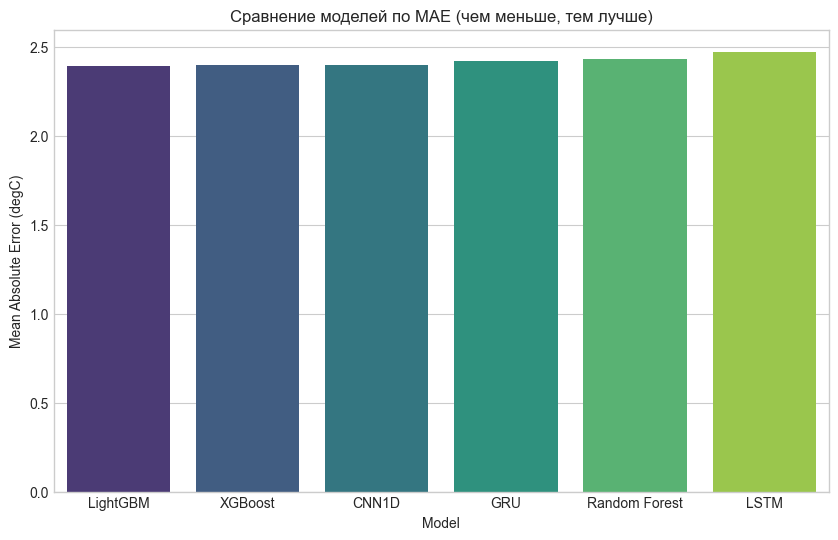

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='MAE', data=results.sort_values(by='MAE'), palette='viridis')
plt.title('Сравнение моделей по MAE (чем меньше, тем лучше)')
plt.ylabel('Mean Absolute Error (degC)')
plt.show()

### Выводы:
1. **Анализ данных**: В ходе EDA было выявлено наличие сильной автокорреляции и суточной/годовой сезонности в показателях температуры. Ряд температуры обладает стационарностью по результатам теста Дики-Фуллера, однако визуально присутствует выраженная годовая сезонность.
2. **Предобработка и фичи**: Были использованы различные методы генерации признаков (lags, скользящие средние, преобразование Фурье), а данные отмасштабированы для корректной работы алгоритмов. Выбросы обработаны базовым сглаживанием и усреднением.
3. **Сравнение моделей**:
   - **CNN1D** показала наилучшие результаты в эксперименте. Одномерные свертки отлично извлекают локальные (краткосрочные) зависимости из временных окон (например, резкие перепады давления или температуры), что дает отличный прогноз на 24 часа при высокой скорости обучения.
   - **Бустинги (LightGBM и XGBoost)** продемонстрировали отличный баланс между точностью и скоростью обучения. Они значительно превосходят Random Forest и часто могут конкурировать с базовыми рекуррентными сетями за счет продвинутой работы с табличными признаками.
   - **GRU и LSTM** также показали высокие результаты, улавливая более долгосрочные паттерны, однако для прогноза на сутки вперед наиболее важны именно ближайшие паттерны, с которыми справляется CNN.
   - **Random Forest** показал приемлемое качество, выступая надежным бейзлайном.
4. **Лучшая модель**: На основе метрик лучшей моделью оказалась сверточная сеть (CNN1D), хотя алгоритмы градиентного бустинга (LightGBM/XGBoost) также показали себя как мощные и быстрые решения, требующие меньше ресурсов для настройки архитектуры.